# Clasificación de prendas con Fashion MNIST y TensorFlow

En este cuaderno vamos a descargar el data set Fashion MNIST con TensorFlow y entrenar una red neuronal que reconozca prendas de vestir.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report

# Semillas para que los resultados sean casi los mismos en cada ejecución
np.random.seed(42)
tf.random.set_seed(42)

print("Versión de TensorFlow:", tf.__version__)

Versión de TensorFlow: 2.20.0


In [8]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ["Camiseta/Top", "Pantalón", "Suéter", "Vestido", "Abrigo",
               "Sandalia", "Camisa", "Zapatilla deportiva", "Bolso", "Botín"]

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:      ", X_test.shape)
print("y_test:      ", y_test.shape)
print("Valor mínimo y máximo de los píxeles:", X_train_full.min(), X_train_full.max())

X_train_full: (60000, 28, 28)
y_train_full: (60000,)
X_test:       (10000, 28, 28)
y_test:       (10000,)
Valor mínimo y máximo de los píxeles: 0 255


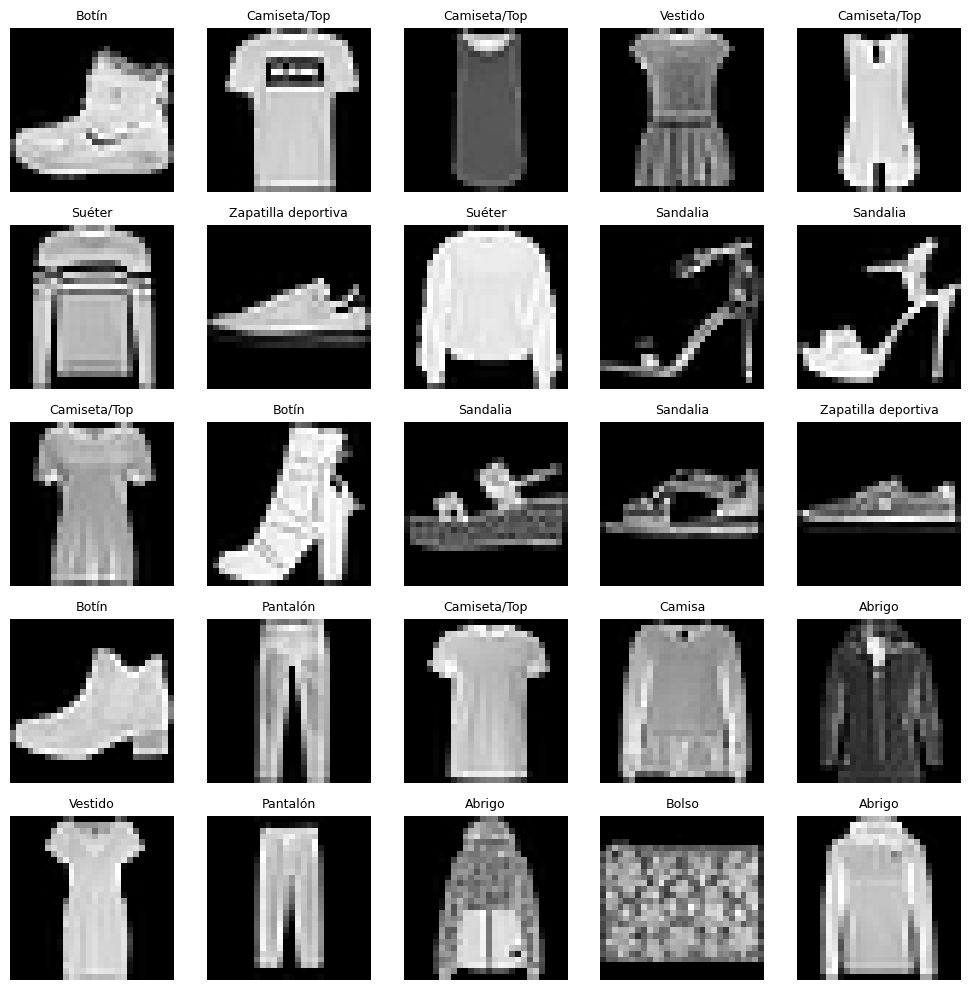

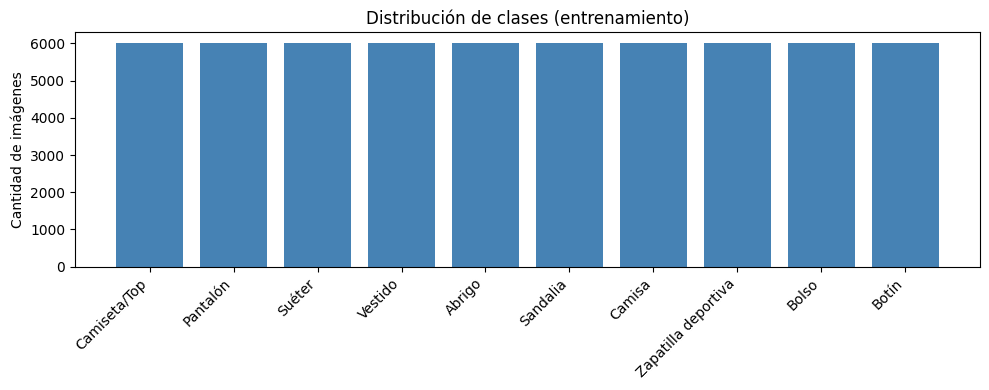

In [9]:
# Cuadrícula con 25 imágenes de ejemplo
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_full[i], cmap="gray")
    plt.title(class_names[y_train_full[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

# Cuántas imágenes hay de cada clase
conteo = np.bincount(y_train_full)
plt.figure(figsize=(10, 4))
plt.bar(class_names, conteo, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de clases (entrenamiento)")
plt.tight_layout()
plt.show()

## Preprocesamiento

Aquí hacemos dos cosas sencillas pero importantes.

**Normalizar.** Los píxeles van de 0 a 255, pero las redes neuronales aprenden mejor con números pequeños. Dividiendo todo entre 255 los dejamos entre 0 y 1. NumPy aplica la división a todo el arreglo de una sola vez, sin necesidad de un ciclo.

**Separar un conjunto de validación.** Con la notación `X[:5000]` tomamos los primeros 5.000 elementos y con `X[5000:]` el resto. Esos 5.000 no se usan para entrenar, sino para ir revisando cómo le va al modelo mientras aprende. Sirve para darnos cuenta a tiempo si está memorizando en vez de aprender.

El resultado son tres grupos:

| Conjunto | Tamaño | Para qué sirve |
|---|---|---|
| Entrenamiento | 55.000 | Ajustar los pesos de la red |
| Validación | 5.000 | Vigilar el aprendizaje sobre la marcha |
| Prueba | 10.000 | Nota final, sin haberlo visto antes |

In [10]:
# Normalizamos: de 0-255 a 0-1
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Separamos validación (primeros 5000) y entrenamiento (el resto)
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

print("Entrenamiento:", X_train.shape)
print("Validación:   ", X_valid.shape)
print("Prueba:       ", X_test.shape)
print("Rango de píxeles ahora:", X_train.min(), "a", X_train.max())

Entrenamiento: (55000, 28, 28)
Validación:    (5000, 28, 28)
Prueba:        (10000, 28, 28)
Rango de píxeles ahora: 0.0 a 1.0


## Construcción del modelo

Usamos `keras.models.Sequential([...])`, que arma la red como una pila de capas: la salida de cada una alimenta a la siguiente.

Las piezas que usamos son:

- **`Flatten`**: convierte la imagen de 28 por 28 en una fila de 784 números. No aprende nada, solo reacomoda los datos para que las capas siguientes puedan leerlos. El parámetro `input_shape` le dice qué tamaño de imagen va a recibir.
- **`Dense`**: una capa donde cada neurona está conectada con todas las de la capa anterior. Cada neurona hace una cuenta sencilla (multiplica por unos pesos, suma un sesgo y aplica una función de activación) y los pesos son lo que la red va aprendiendo.
- **`relu`**: función de activación que deja pasar los números positivos y convierte los negativos en cero. Es simple, rápida y le da a la red la capacidad de aprender cosas que no son líneas rectas. Sin activaciones, muchas capas serían equivalentes a una sola.
- **`softmax`**: se usa en la última capa. Convierte las 10 salidas en probabilidades que suman 1, así que podemos leer algo como "80 % pantalón, 15 % vestido...".
- **`Dropout(0.2)`**: en cada paso del entrenamiento apaga al azar el 20 % de las neuronas. Suena raro, pero obliga a la red a no depender de neuronas específicas y ayuda a que no memorice. Al evaluar o predecir se desactiva solo.

Al final `model.summary()` muestra las capas, el tamaño de cada salida y cuántos parámetros (pesos) tiene el modelo. Es útil para confirmar que armamos lo que queríamos.

In [11]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),        # imagen 28x28 -> vector de 784
    keras.layers.Dense(128, activation="relu"),         # primera capa oculta
    keras.layers.Dropout(0.2),                          # apaga 20% de neuronas al entrenar
    keras.layers.Dense(64, activation="relu"),          # segunda capa oculta
    keras.layers.Dense(10, activation="softmax"),       # salida: una probabilidad por clase
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compilación

Antes de entrenar hay que decirle al modelo cómo va a aprender, y eso se hace con `model.compile()`. Recibe tres cosas:

| Parámetro | Valor | Qué significa |
|---|---|---|
| `loss` | `sparse_categorical_crossentropy` | La función de pérdida, que mide qué tan equivocadas están las predicciones. Usamos la versión "sparse" porque nuestras etiquetas son números enteros (0 a 9) y no vectores. |
| `optimizer` | `adam` | El algoritmo que ajusta los pesos para bajar la pérdida. Adam es popular porque ajusta solo su ritmo de aprendizaje y suele funcionar bien sin mucha configuración. |
| `metrics` | `accuracy` | Lo que queremos ver reportado: el porcentaje de prendas bien clasificadas. |

In [12]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

## Entrenamiento

`model.fit()` es donde ocurre el aprendizaje. Los parámetros que usamos:

| Parámetro | Qué hace |
|---|---|
| `X_train, y_train` | Las imágenes y etiquetas de entrenamiento |
| `epochs=30` | Máximo de pasadas completas por todos los datos |
| `batch_size=32` | Cuántas imágenes ve la red antes de corregir sus pesos |
| `validation_data` | Datos que se usan solo para medir, nunca para aprender |
| `callbacks` | Funciones que se ejecutan mientras se entrena |

El callback que usamos es **`EarlyStopping`**. Vigila la pérdida de validación y, si no mejora durante 5 épocas seguidas (`patience=5`), detiene el entrenamiento. Con `restore_best_weights=True` se queda con los pesos de la mejor época, no con los de la última. Es como dejar de estudiar cuando ya no estás aprendiendo nada nuevo.

`fit` devuelve un objeto `history` con la pérdida y la precisión de cada época, que usamos enseguida para graficar.

In [13]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8049 - loss: 0.5470 - val_accuracy: 0.8604 - val_loss: 0.3866
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8483 - loss: 0.4115 - val_accuracy: 0.8732 - val_loss: 0.3514
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8607 - loss: 0.3781 - val_accuracy: 0.8750 - val_loss: 0.3422
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8691 - loss: 0.3552 - val_accuracy: 0.8846 - val_loss: 0.3237
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8741 - loss: 0.3386 - val_accuracy: 0.8806 - val_loss: 0.3243
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8781 - loss: 0.3262 - val_accuracy: 0.8870 - val_loss: 0.3163
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8826 - loss: 0.3162 - val_accuracy: 0.8898 - val_loss: 0.3094
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8848 - loss: 0.30

### Curvas de aprendizaje

Estas gráficas muestran cómo cambió el error y la precisión en cada época, tanto con los datos de entrenamiento como con los de validación. Lo que hay que buscar es la separación entre las dos líneas. Si en entrenamiento la precisión sigue subiendo pero en validación se queda quieta, o la pérdida de validación empieza a subir, el modelo está memorizando (sobreajuste).

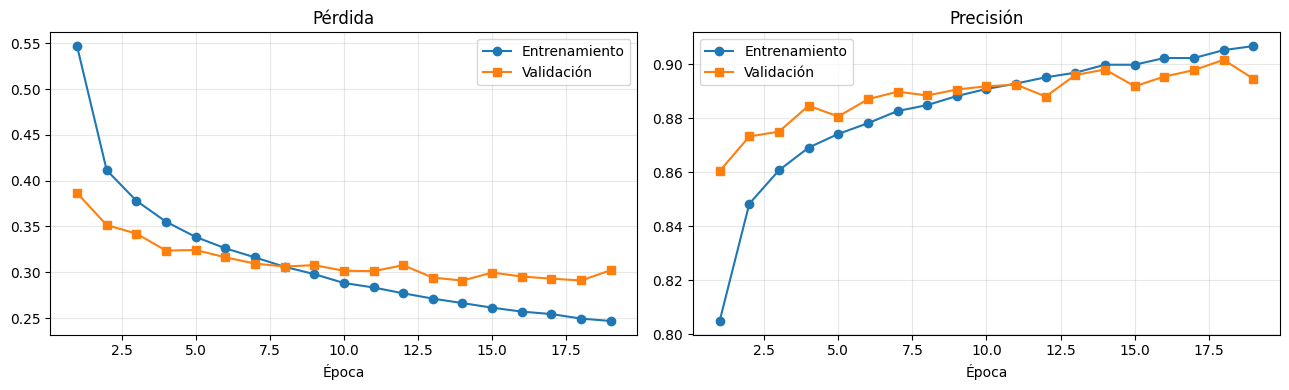

In [14]:
hist = history.history
epocas = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epocas, hist["loss"], "o-", label="Entrenamiento")
axes[0].plot(epocas, hist["val_loss"], "s-", label="Validación")
axes[0].set_title("Pérdida")
axes[0].set_xlabel("Época")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epocas, hist["accuracy"], "o-", label="Entrenamiento")
axes[1].plot(epocas, hist["val_accuracy"], "s-", label="Validación")
axes[1].set_title("Precisión")
axes[1].set_xlabel("Época")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluación

Ahora viene la nota final. `model.evaluate()` mide el desempeño con las 10.000 imágenes de prueba, que el modelo nunca vio. Devuelve la pérdida y la precisión. Este es el número que realmente dice qué tan bien generaliza la red.

In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Precisión en prueba: {test_acc:.4f} ({test_acc*100:.2f} %)")
print(f"Pérdida en prueba:   {test_loss:.4f}")

Precisión en prueba: 0.8850 (88.50 %)
Pérdida en prueba:   0.3321


## Predicciones

Para ver qué responde el modelo con cada imagen usamos dos funciones:

- **`model.predict(X)`** devuelve una tabla con 10 probabilidades por imagen, una por clase.
- **`np.argmax(arreglo, axis=1)`** toma cada fila y devuelve la posición de la probabilidad más alta, o sea, la clase que el modelo eligió.

En las imágenes de abajo, el título en azul significa acierto y en rojo significa error. El porcentaje es la seguridad que tenía el modelo en su respuesta.

Probabilidades para la imagen 0:
  Camiseta/Top           0.000
  Pantalón               0.000
  Suéter                 0.000
  Vestido                0.000
  Abrigo                 0.000
  Sandalia               0.007
  Camisa                 0.000
  Zapatilla deportiva    0.018
  Bolso                  0.000
  Botín                  0.974

Predicción: Botín  |  Real: Botín


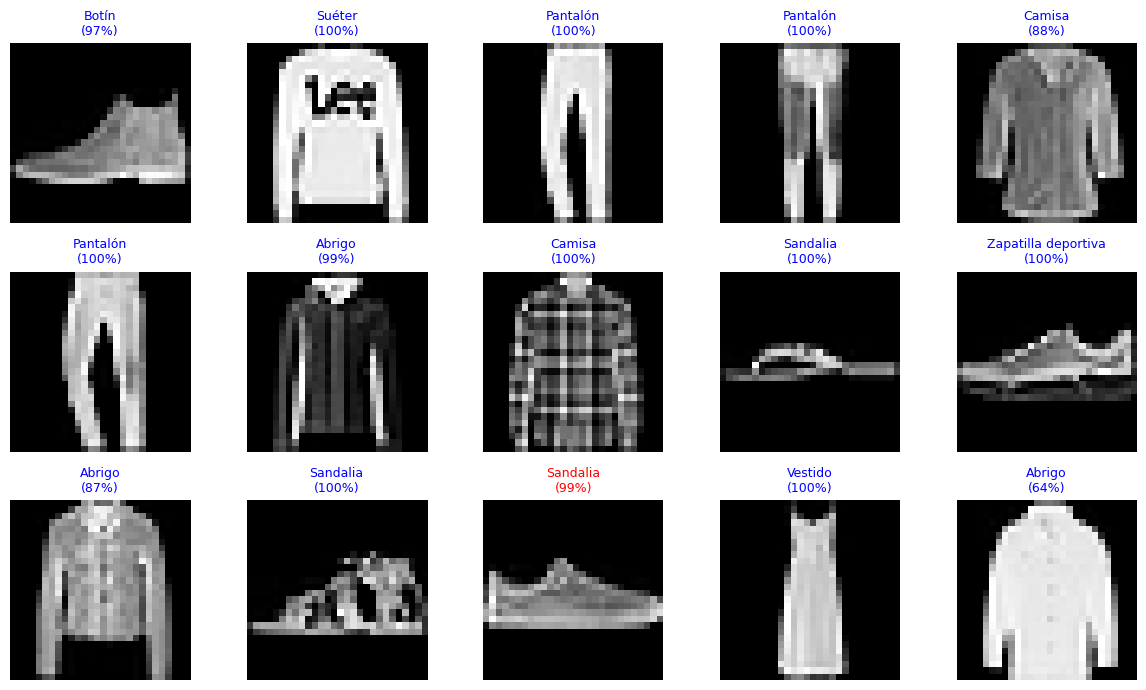

In [16]:
y_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

# Vemos con detalle qué pensó el modelo de la primera imagen de prueba
print("Probabilidades para la imagen 0:")
for nombre, p in zip(class_names, y_proba[0]):
    print(f"  {nombre:22s} {p:.3f}")
print(f"\nPredicción: {class_names[y_pred[0]]}  |  Real: {class_names[y_test[0]]}")

# 15 predicciones: azul acierta, rojo se equivoca
plt.figure(figsize=(12, 7))
for k in range(15):
    plt.subplot(3, 5, k + 1)
    plt.imshow(X_test[k], cmap="gray")
    plt.axis("off")
    acierto = y_pred[k] == y_test[k]
    plt.title(f"{class_names[y_pred[k]]}\n({100*y_proba[k].max():.0f}%)",
              color="blue" if acierto else "red", fontsize=9)
plt.tight_layout()
plt.show()

## Análisis de errores

La precisión total es un solo número y no dice en qué se equivoca el modelo. Para eso usamos dos herramientas de scikit-learn:

- **`confusion_matrix(y_real, y_pred)`** arma una tabla de 10 por 10. Cada fila es la clase real y cada columna la que predijo el modelo. Si todo estuviera perfecto, solo tendríamos números en la diagonal. Lo que queda fuera de la diagonal son las confusiones.
- **`classification_report()`** da tres métricas por clase. La *precision* responde "de lo que el modelo llamó X, ¿cuánto era realmente X?". El *recall* responde "de todo lo que era X, ¿cuánto encontró el modelo?". El *F1* mezcla las dos en un solo número.

Además calculamos el acierto por clase (la diagonal dividida entre el total de cada fila) para ver cuáles prendas son fáciles y cuáles difíciles, y listamos las confusiones más frecuentes.

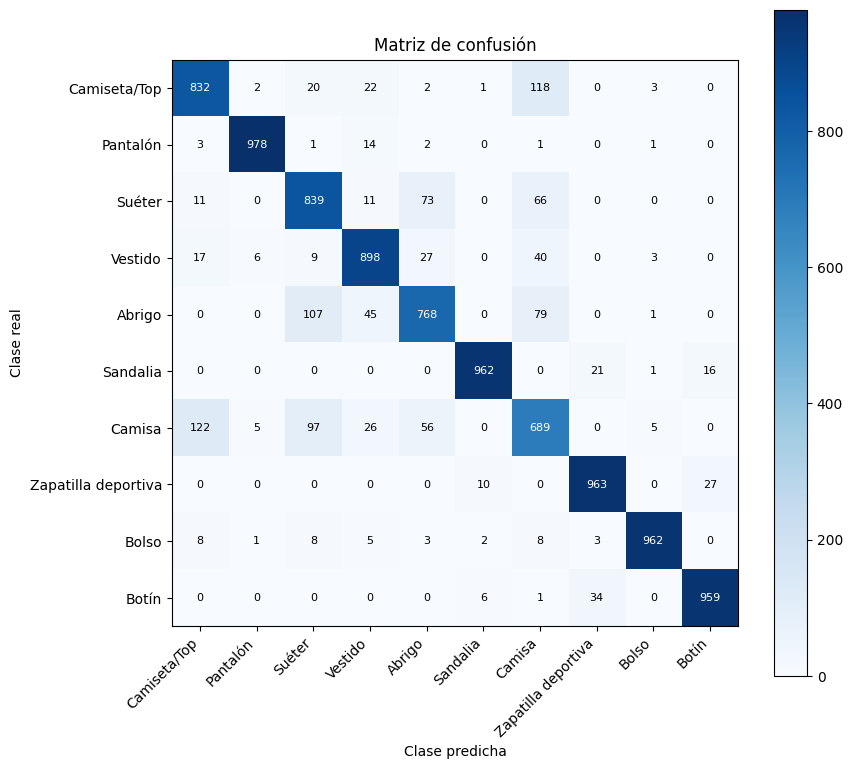

                     precision    recall  f1-score   support

       Camiseta/Top      0.838     0.832     0.835      1000
           Pantalón      0.986     0.978     0.982      1000
             Suéter      0.776     0.839     0.806      1000
            Vestido      0.880     0.898     0.889      1000
             Abrigo      0.825     0.768     0.795      1000
           Sandalia      0.981     0.962     0.971      1000
             Camisa      0.688     0.689     0.688      1000
Zapatilla deportiva      0.943     0.963     0.953      1000
              Bolso      0.986     0.962     0.974      1000
              Botín      0.957     0.959     0.958      1000

           accuracy                          0.885     10000
          macro avg      0.886     0.885     0.885     10000
       weighted avg      0.886     0.885     0.885     10000

Clase más difícil: Camisa (68.9 %)
Clase más fácil:   Pantalón (97.8 %)

Las 5 confusiones más frecuentes (real -> predicha):
  Camisa         

In [17]:
cm = confusion_matrix(y_test, y_pred)

# Matriz de confusión como mapa de calor
plt.figure(figsize=(9, 8))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)
for r in range(10):
    for c in range(10):
        plt.text(c, r, cm[r, c], ha="center", va="center",
                 color="white" if cm[r, c] > cm.max() / 2 else "black", fontsize=8)
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

# Cuáles clases son fáciles y cuáles difíciles
acc_por_clase = cm.diagonal() / cm.sum(axis=1)
orden = np.argsort(acc_por_clase)
print(f"Clase más difícil: {class_names[orden[0]]} ({acc_por_clase[orden[0]]*100:.1f} %)")
print(f"Clase más fácil:   {class_names[orden[-1]]} ({acc_por_clase[orden[-1]]*100:.1f} %)")

# Las confusiones más frecuentes (quitamos la diagonal para no contar aciertos)
cm_sin_diag = cm.copy()
np.fill_diagonal(cm_sin_diag, 0)
print("\nLas 5 confusiones más frecuentes (real -> predicha):")
top = np.dstack(np.unravel_index(np.argsort(-cm_sin_diag.ravel())[:5], cm.shape))[0]
for real, pred in top:
    print(f"  {class_names[real]:20s} -> {class_names[pred]:20s}: {cm_sin_diag[real, pred]} veces")

## Comparación con una red convolucional

La red que armamos hasta ahora tiene una limitación: al aplanar la imagen con `Flatten`, pierde la información de qué píxeles están cerca de cuáles. Para la red, el píxel de la esquina y el del centro son solo dos números más en una fila.

Una red convolucional (CNN) resuelve eso porque mira la imagen por pedacitos. Para comparar, entrenamos una CNN pequeña con el mismo proceso. Las capas nuevas son:

- **`Conv2D(filtros, 3)`**: desliza filtros pequeños de 3 por 3 sobre la imagen para detectar patrones locales, como bordes o texturas. Con `padding="same"` la imagen conserva su tamaño.
- **`MaxPooling2D(2)`**: reduce la imagen a la mitad quedándose con el valor más grande de cada bloque de 2 por 2. Así hay menos datos y la red tolera pequeños desplazamientos.
- **`X[..., np.newaxis]`**: las convoluciones esperan una dimensión extra de canal (1 para escala de grises), y esta instrucción la agrega.

In [18]:
# Agregamos la dimensión del canal: (n, 28, 28) -> (n, 28, 28, 1)
X_train_c = X_train[..., np.newaxis]
X_valid_c = X_valid[..., np.newaxis]
X_test_c  = X_test[..., np.newaxis]

cnn = keras.models.Sequential([
    keras.layers.Conv2D(32, 3, activation="relu", padding="same", input_shape=[28, 28, 1]),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation="softmax"),
])
cnn.summary()

cnn.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

history_cnn = cnn.fit(
    X_train_c, y_train,
    epochs=15, batch_size=64,
    validation_data=(X_valid_c, y_valid),
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=1,
)

cnn_loss, cnn_acc = cnn.evaluate(X_test_c, y_test, verbose=0)

print("\n" + "=" * 45)
print(f"  Red densa: {test_acc*100:.2f} % en prueba")
print(f"  CNN:       {cnn_acc*100:.2f} % en prueba")
print(f"  Diferencia: {(cnn_acc - test_acc)*100:+.2f} puntos")
print("=" * 45)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 66s 74ms/step - accuracy: 0.8053 - loss: 0.5463 - val_accuracy: 0.8838 - val_loss: 0.3262
Epoch 2/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 62s 72ms/step - accuracy: 0.8756 - loss: 0.3496 - val_accuracy: 0.8968 - val_loss: 0.2810
Epoch 3/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.8894 - loss: 0.3018 - val_accuracy: 0.9060 - val_loss: 0.2578
Epoch 4/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 62s 72ms/step - accuracy: 0.9014 - loss: 0.2715 - val_accuracy: 0.9086 - val_loss: 0.2495
Epoch 5/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.9112 - loss: 0.2464 - val_accuracy: 0.9148 - val_loss: 0.2353
Epoch 6/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 61s 71ms/step - accuracy: 0.9160 - loss: 0.2311 - val_accuracy: 0.9158 - val_loss: 0.2281
Epoch 7/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 84s 73ms/step - accuracy: 0.9227 - loss: 0.2124 - val_accuracy: 0.9208 - val_loss: 0.2218
Epoch 8/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 62s 72ms/step - accuracy: 0.9270 - loss: 0.1987 - 

## Glosario de funciones

| Función o instrucción | Librería | Para qué sirve |
|---|---|---|
| `fashion_mnist.load_data()` | Keras | Descargar y cargar el data set |
| `.shape` | NumPy | Ver las dimensiones de un arreglo |
| `np.bincount()` | NumPy | Contar cuántas veces aparece cada clase |
| `X / 255.0` | NumPy | Normalizar los píxeles a valores entre 0 y 1 |
| `X[:5000]` y `X[5000:]` | NumPy | Separar validación y entrenamiento |
| `plt.imshow()` y `plt.subplot()` | Matplotlib | Mostrar imágenes en cuadrícula |
| `Sequential([...])` | Keras | Apilar capas una tras otra |
| `Flatten` | Keras | Aplanar la imagen en un vector |
| `Dense` | Keras | Capa donde todas las neuronas se conectan con todas |
| `relu` y `softmax` | Keras | Activación de capas ocultas y de la salida |
| `Dropout` | Keras | Apagar neuronas al azar para evitar memorización |
| `Conv2D` y `MaxPooling2D` | Keras | Detectar patrones locales y reducir el tamaño |
| `model.summary()` | Keras | Resumen de capas y parámetros |
| `model.compile()` | Keras | Definir pérdida, optimizador y métricas |
| `model.fit()` | Keras | Entrenar el modelo |
| `EarlyStopping` | Keras | Parar cuando el modelo ya no mejora |
| `model.evaluate()` | Keras | Medir el desempeño con datos de prueba |
| `model.predict()` | Keras | Obtener las probabilidades por clase |
| `np.argmax()` | NumPy | Elegir la clase con mayor probabilidad |
| `confusion_matrix()` | scikit-learn | Ver qué clases se confunden entre sí |
| `classification_report()` | scikit-learn | Precision, recall y F1 por clase |

## Conclusiones

Los números exactos cambian un poco de una ejecución a otra. Con esta configuración lo normal es ver alrededor de 87 a 89 % en prueba para la red densa y de 90 a 92 % para la CNN. Vale la pena comparar estas ideas con las cifras que salieron en su propia ejecución.

**Una red sencilla ya hace un buen trabajo.** Con dos capas ocultas y pocos minutos de entrenamiento, el modelo clasifica bien la gran mayoría de las prendas, muy por encima del 10 % que se obtendría al azar.

**Preparar bien los datos pesa.** Normalizar los píxeles hace que el entrenamiento sea más estable, y tener un conjunto de validación separado permite darse cuenta del sobreajuste sin gastar los datos de prueba.

**Regularizar ayuda, pero no hace magia.** `Dropout` y `EarlyStopping` reducen la diferencia entre lo que el modelo logra al entrenar y lo que logra en prueba, aunque casi siempre queda una brecha pequeña.

**Los errores se concentran en prendas parecidas.** La camisa, la camiseta, el suéter y el abrigo se confunden entre sí porque, a 28 por 28 píxeles y sin color, tienen siluetas casi iguales. En cambio el pantalón, el bolso y el calzado se reconocen muy bien porque su forma es muy distinta a la del resto. La camisa suele ser la clase más difícil.

**La precisión es una métrica confiable aquí.** Como todas las clases tienen la misma cantidad de imágenes, un solo porcentaje no esconde que el modelo ignore alguna clase.

**La arquitectura importa.** La red densa pierde la relación entre píxeles vecinos por el `Flatten`, y la CNN sí la aprovecha, por eso suele quedar por encima. Esto muestra que para imágenes conviene usar capas pensadas para imágenes.

**Qué se podría probar después.** Más filtros o capas convolucionales, aumento de datos (girar o desplazar un poco las imágenes), `BatchNormalization`, ajustar la tasa de aprendizaje o usar transferencia de aprendizaje.